# EDA - MIAX14 Hackathon
Exploración de los datos de entrenamiento para los 6 índices bursátiles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='darkgrid')

DATA = '../data'

In [2]:
idx = pd.read_csv(f'{DATA}/train_indices.csv', parse_dates=['Date'], index_col='Date')
macro = pd.read_csv(f'{DATA}/train_macro_factors.csv', parse_dates=['Date'], index_col='Date')
net = pd.read_csv(f'{DATA}/train_network_metrics.csv', parse_dates=['Date'], index_col='Date')
news = pd.read_csv(f'{DATA}/train_news.csv', parse_dates=['Date'])

print('Index data shape:', idx.shape)
print('Date range:', idx.index.min(), '->', idx.index.max())
idx.head()

Index data shape: (11956, 6)
Date range: 1985-06-24 00:00:00 -> 2028-12-12 00:00:00


,Index_A,Index_B,Index_C,Index_D,Index_E,Index_F
Date,,,,,,
1985-06-24,1000.0,1000.000000,1000.000000,1000.0,1000.000000,1000.0
1985-06-25,1000.0,999.488230,994.662881,1000.0,1001.789362,1000.0
1985-06-26,1000.0,1011.748234,996.438165,1000.0,1005.643892,1000.0
1985-06-29,1000.0,1010.288631,994.086365,1000.0,1007.807803,1000.0
1985-06-30,1000.0,1027.782866,1003.471124,1000.0,1027.756065,1000.0


## 1. Series temporales de los índices

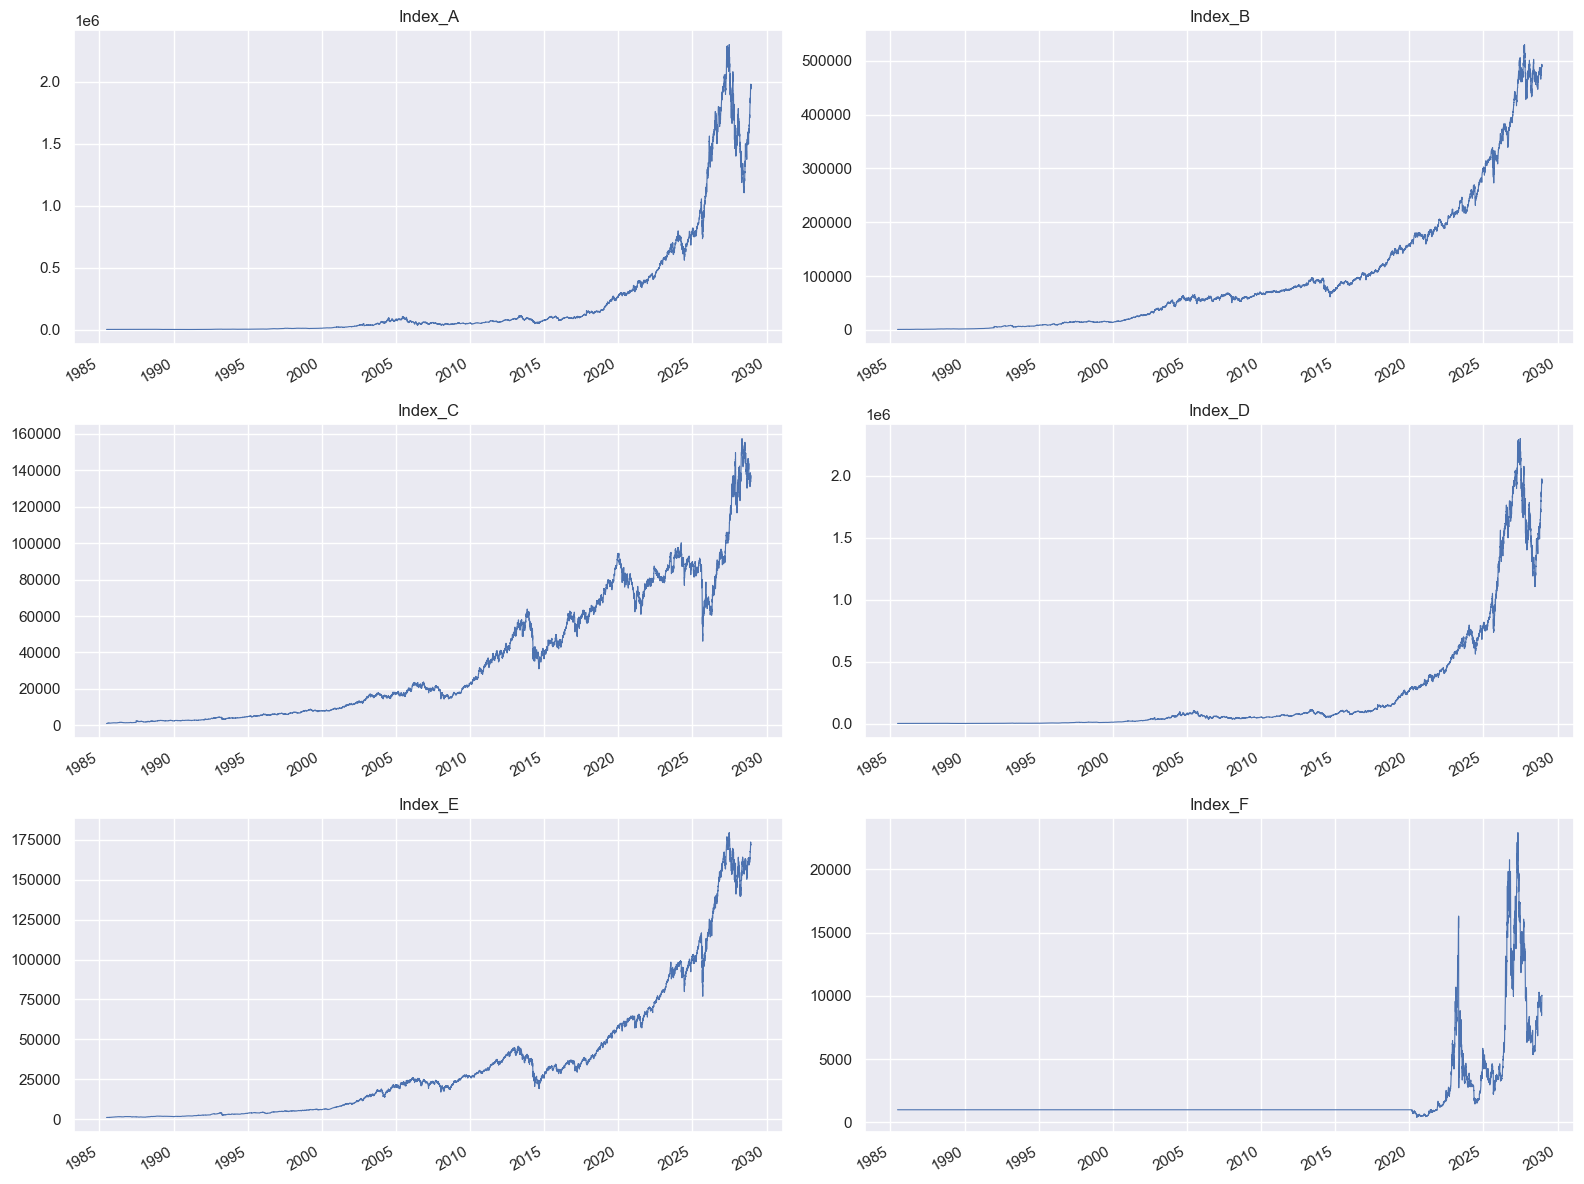

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for ax, col in zip(axes.flatten(), idx.columns):
    idx[col].plot(ax=ax, title=col, lw=0.8)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 2. Estadísticas descriptivas y correlaciones

In [4]:
idx.describe().round(2)

,Index_A,Index_B,Index_C,Index_D,Index_E,Index_F
count,11956.00,11956.00,11956.00,11956.00,11956.00,11956.00
mean,284087.48,112522.48,40017.78,283976.94,40706.43,2200.17
std,493808.86,130284.61,37973.74,493663.99,45349.04,3294.31
min,382.61,865.46,986.54,383.33,971.73,389.44
25%,7808.29,14240.17,6188.50,7808.17,4762.30,1000.00
50%,58340.42,64661.94,21611.00,58320.12,24550.71,1000.00
75%,302841.03,175336.80,72794.87,302569.35,60782.16,1000.00
max,2298218.36,529856.92,157471.41,2301550.11,179652.32,22908.69


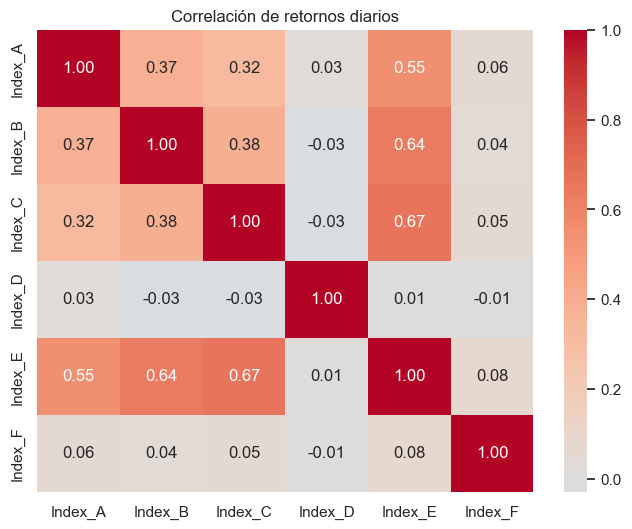

In [5]:
returns = idx.pct_change().dropna()
corr = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación de retornos diarios')
plt.show()

## 3. Index_D - The Ghost (señal oculta)
Buscamos qué índice sigue Index_D con más correlación en niveles y retornos.

In [6]:
# Buscar desfases que maximizan correlación con Index_D
results = []
for col in ['Index_A', 'Index_B', 'Index_C', 'Index_E', 'Index_F']:
    for lag in range(0, 31):
        shifted = idx[col].shift(lag)
        corr_val = idx['Index_D'].corr(shifted)
        results.append({'source': col, 'lag': lag, 'corr': corr_val})

res_df = pd.DataFrame(results).sort_values('corr', ascending=False)
print('Top 10 correlations with Index_D:')
print(res_df.head(10).to_string(index=False))

Top 10 correlations with Index_D:
 source  lag     corr
Index_A    1 0.999997
Index_A    0 0.999824
Index_A    2 0.999822
Index_A    3 0.999671
Index_A    4 0.999524
Index_A    5 0.999380
Index_A    6 0.999231
Index_A    7 0.999095
Index_A    8 0.998942
Index_A    9 0.998791


## 4. Factores macroeconómicos

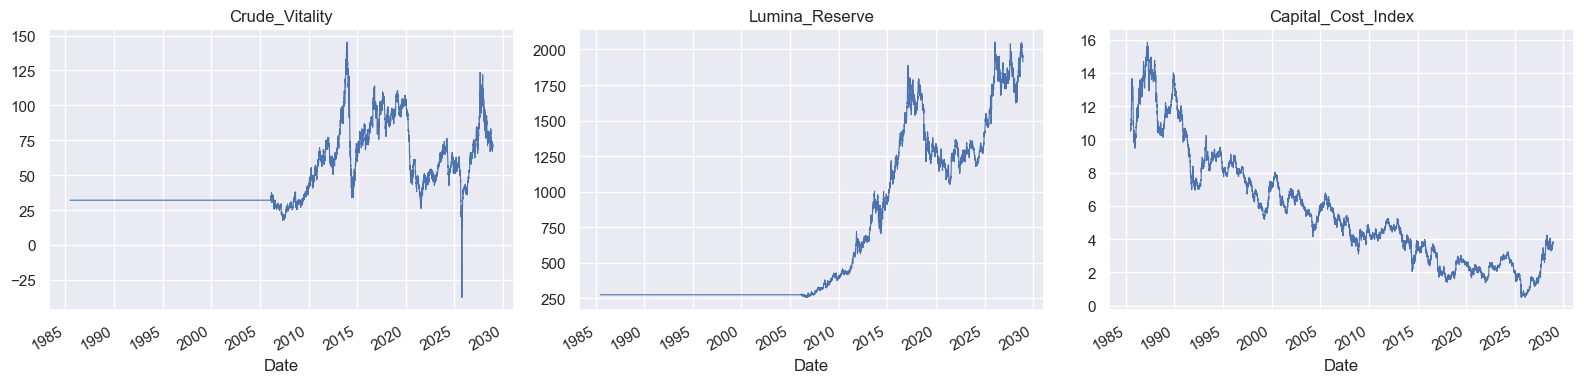

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, macro.columns):
    macro[col].plot(ax=ax, title=col, lw=0.8)
plt.tight_layout()
plt.show()

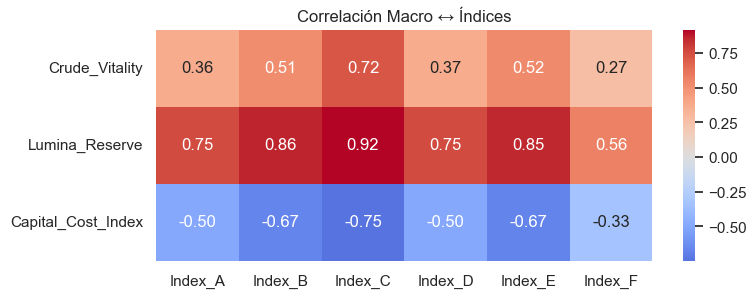

In [8]:
# Correlación de macro con índices
combined = idx.join(macro)
corr_macro = combined.corr().loc[macro.columns, idx.columns]
plt.figure(figsize=(8, 3))
sns.heatmap(corr_macro, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación Macro ↔ Índices')
plt.show()

## 5. Network metrics (Index_F)

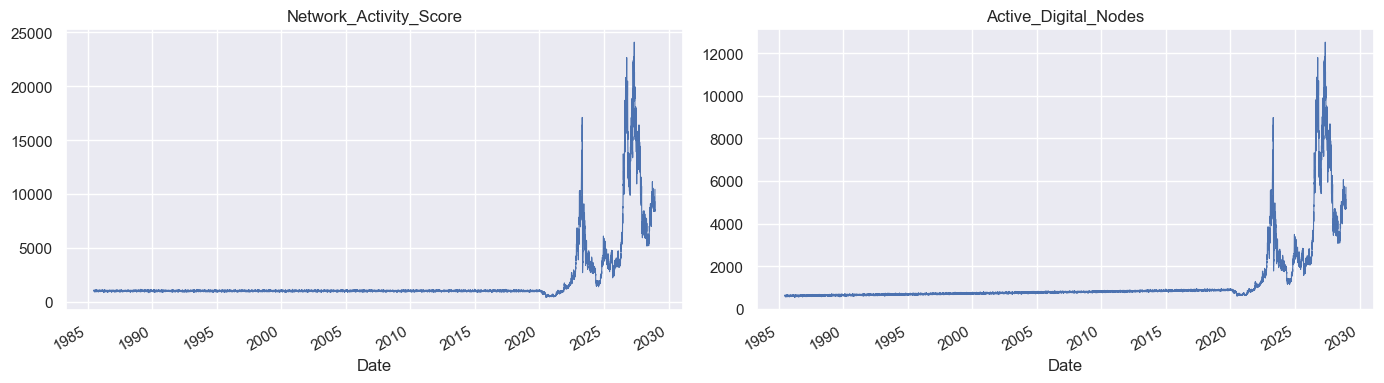

                         Index_F  Network_Activity_Score  Active_Digital_Nodes
Index_F                 1.000000                0.998642              0.997210
Network_Activity_Score  0.998642                1.000000              0.998454
Active_Digital_Nodes    0.997210                0.998454              1.000000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, net.columns):
    net[col].plot(ax=ax, title=col, lw=0.8)
plt.tight_layout()
plt.show()

# Correlación con Index_F
combined_f = idx['Index_F'].to_frame().join(net)
print(combined_f.corr())

## 6. Análisis de noticias

In [10]:
print('Tickers únicos:', news['Ticker_Anonymized'].nunique())
print('\nTop tickers por frecuencia:')
print(news['Ticker_Anonymized'].value_counts().head(15))

Tickers únicos: 12

Top tickers por frecuencia:
Ticker_Anonymized
Janus Chips         4867
Boreas Computing    4849
Eos Energy          4828
Aether Systems      4804
Icarus Motors       4801
Gaia Health         4793
Fafnir Finance      4779
Chronos Search      4766
Dione Logistics     4747
Hestia Goods        4744
Prometheus Chain    4735
Hermes Digital      4680
Name: count, dtype: int64


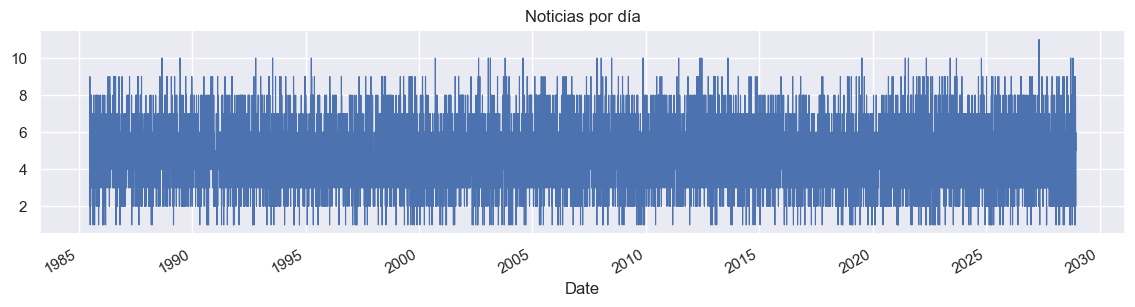

In [11]:
news_daily = news.groupby('Date').size().rename('news_count')
news_daily.plot(title='Noticias por día', figsize=(14, 3), lw=0.8)
plt.show()

## 7. Datos de test - rango de fechas a predecir

In [12]:
test_macro = pd.read_csv(f'{DATA}/test_macro_factors.csv', parse_dates=['Date'], index_col='Date')
test_net = pd.read_csv(f'{DATA}/test_network_metrics.csv', parse_dates=['Date'], index_col='Date')

print(f'Fechas a predecir: {test_macro.index.min()} -> {test_macro.index.max()}')
print(f'Total días de test: {len(test_macro)}')
print('\nTest macro stats:')
test_macro.describe().round(2)

Fechas a predecir: 2028-12-13 00:00:00 -> 2029-08-21 00:00:00
Total días de test: 173

Test macro stats:


,Crude_Vitality,Lumina_Reserve,Capital_Cost_Index
count,173.00,173.0,173.00
mean,78.77,1967.8,4.24
std,6.12,59.1,0.31
min,67.70,1816.6,3.71
25%,73.86,1921.7,4.01
50%,77.87,1968.9,4.21
75%,82.82,2022.3,4.42
max,93.68,2081.9,4.99
